# Spotify Song Popularity — Capstone Project
### Combined Notebook: EDA → Feature Engineering → Regression Models → Evaluation

**Goal:** Predict a song's popularity score (0–100) from its audio features using the Spotify dataset.  
**Dataset:** ~170,000 tracks · 19 columns · Source: Count.co / Course Case Study (GitHub)  
**Target variable:** `popularity` (continuous, 0–100)  

**Approach:**
1. Load and inspect the data
2. Engineer an artist-level popularity feature
3. Fit Linear Regression (baseline + with artist feature)
4. Check whether standardization changes results
5. Fit Random Forest and XGBoost
6. Compare all models and inspect feature importance


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('spotify_data 2.csv')
print('Shape:', df.shape)
df.head()

Shape: (169909, 19)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.990,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169909 entries, 0 to 169908
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   acousticness      169909 non-null  float64
 1   artists           169909 non-null  object 
 2   danceability      169909 non-null  float64
 3   duration_ms       169909 non-null  int64  
 4   energy            169909 non-null  float64
 5   explicit          169909 non-null  int64  
 6   id                169909 non-null  object 
 7   instrumentalness  169909 non-null  float64
 8   key               169909 non-null  int64  
 9   liveness          169909 non-null  float64
 10  loudness          169909 non-null  float64
 11  mode              169909 non-null  int64  
 12  name              169909 non-null  object 
 13  popularity        169909 non-null  int64  
 14  release_date      169909 non-null  object 
 15  speechiness       169909 non-null  float64
 16  tempo             16

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
acousticness,169909.0,0.493214,0.376627,0.0,0.0945,0.492000,0.8880,0.996
danceability,169909.0,0.538150,0.175346,0.0,0.4170,0.548000,0.6670,0.988
duration_ms,169909.0,231406.158973,121321.923219,5108.0,171040.0000,208600.000000,262960.0000,5403500.000
energy,169909.0,0.488593,0.267390,0.0,0.2630,0.481000,0.7100,1.000
explicit,169909.0,0.084863,0.278679,0.0,0.0000,0.000000,0.0000,1.000
instrumentalness,169909.0,0.161937,0.309329,0.0,0.0000,0.000204,0.0868,1.000
key,169909.0,5.200519,3.515257,0.0,2.0000,5.000000,8.0000,11.000
liveness,169909.0,0.206690,0.176796,0.0,0.0984,0.135000,0.2630,1.000
loudness,169909.0,-11.370289,5.666765,-60.0,-14.4700,-10.474000,-7.1180,3.855
mode,169909.0,0.708556,0.454429,0.0,0.0000,1.000000,1.0000,1.000


In [5]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with missing values
df = df.dropna().reset_index(drop=True)
print(f'\nRows after dropping nulls: {len(df)}')

Missing values per column:
Series([], dtype: int64)

Rows after dropping nulls: 169909


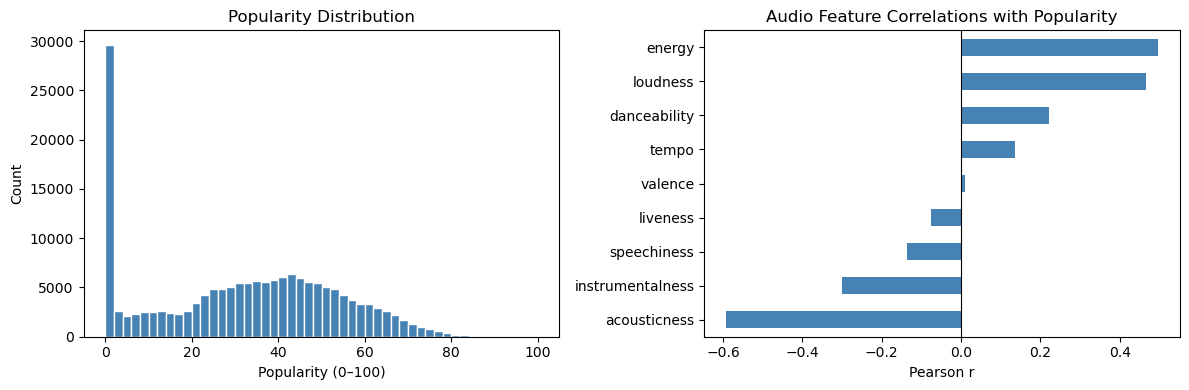

In [6]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity (0–100)')
axes[0].set_ylabel('Count')

audio_features = ['danceability', 'energy', 'valence', 'tempo',
                   'loudness', 'acousticness', 'speechiness',
                   'instrumentalness', 'liveness']

corrs = df[audio_features + ['popularity']].corr()['popularity'].drop('popularity').sort_values()
corrs.plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_title('Audio Feature Correlations with Popularity')
axes[1].set_xlabel('Pearson r')
axes[1].axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

## 2. Feature Engineering: Artist Average Popularity

Songs by established artists tend to be more popular — not because of audio features, but because of fanbase size.  
We capture this with a simple feature: **the artist's average track popularity across all their songs in the dataset.**


In [7]:
import ast

# Extract primary artist (first name in the list)
def primary_artist(val):
    try:
        parsed = ast.literal_eval(val)
        return parsed[0] if isinstance(parsed, list) and len(parsed) > 0 else val
    except:
        return val

df['primary_artist'] = df['artists'].apply(primary_artist)

# Artist avg popularity = mean of top 10 most popular tracks per artist
# Using top 10 (not all tracks) so prolific artists with large back catalogs
# are not penalised — this captures hit-making ability
top10_mean = (
    df[df['popularity'] > 0]
    .groupby('primary_artist')['popularity']
    .apply(lambda x: x.nlargest(10).mean())
    .rename('artist_avg_popularity')
)
df = df.join(top10_mean, on='primary_artist')
df['artist_avg_popularity'] = df['artist_avg_popularity'].fillna(df['popularity'].median())

r = df['artist_avg_popularity'].corr(df['popularity'])
print(f'Correlation — artist_avg_popularity vs popularity: {r:.4f}')

# Spot check
for artist in ['Taylor Swift', 'Drake', 'Billie Eilish', 'Ed Sheeran']:
    val = top10_mean.get(artist)
    if val:
        print(f'  {artist}: {val:.1f}')

Correlation of artist_avg_popularity with popularity: 0.9243


,popularity,artist_avg_popularity
0,0,0.000000
1,0,4.019608
2,0,0.000000
3,0,0.041578
4,1,2.062147
5,0,0.923077
6,0,8.982143
7,0,0.000000
8,0,0.023965
9,0,0.000000


## 3. Select Features & Train-Test Split

We define two feature sets:
- **Baseline** — 13 audio features only (no artist info)
- **Full** — audio features + `artist_avg_popularity` + `year`


In [8]:
drop_cols = ['id', 'name', 'artists', 'release_date', 'popularity']

# Full feature set (audio + artist_avg_popularity + year)
X_full = df.drop(columns=drop_cols)
y = df['popularity']

# Baseline feature set (audio features only — drop artist and year)
audio_cols = ['danceability', 'energy', 'key', 'loudness', 'mode',
              'speechiness', 'acousticness', 'instrumentalness',
              'liveness', 'valence', 'tempo', 'duration_ms', 'explicit']
X_base = df[audio_cols]

print('Full feature set shape:', X_full.shape)
print('Baseline feature set shape:', X_base.shape)
print('Target shape:', y.shape)

Full feature set shape: (169909, 15)
Baseline feature set shape: (169909, 13)
Target shape: (169909,)


In [9]:
# 80 / 20 split — same random state throughout
X_full_train, X_full_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

X_base_train, X_base_test = (
    X_full_train[audio_cols],
    X_full_test[audio_cols]
)

print(f'Train size: {len(X_full_train):,}   Test size: {len(X_full_test):,}')

Train size: 135,927   Test size: 33,982


## 4. Linear Regression — Baseline (Audio Features Only)

This replicates the case study Part 2: fit a simple linear regression on the 13 audio features.


In [10]:
lr_base = LinearRegression()
lr_base.fit(X_base_train, y_train)

y_train_pred_base = lr_base.predict(X_base_train)
y_test_pred_base  = lr_base.predict(X_base_test)

r2_train_base   = r2_score(y_train, y_train_pred_base)
rmse_train_base = np.sqrt(mean_squared_error(y_train, y_train_pred_base))
r2_test_base    = r2_score(y_test, y_test_pred_base)
rmse_test_base  = np.sqrt(mean_squared_error(y_test, y_test_pred_base))

print('Linear Regression — Baseline (Audio Features Only)')
print(f'  Train — R²: {r2_train_base:.4f}  RMSE: {rmse_train_base:.4f}')
print(f'  Test  — R²: {r2_test_base:.4f}  RMSE: {rmse_test_base:.4f}')

Linear Regression — Baseline (Audio Features Only)
  Train — R²: 0.4680  RMSE: 15.7366
  Test  — R²: 0.4675  RMSE: 15.7680


## 5. Linear Regression — With Artist Popularity

Adding `artist_avg_popularity` and `year` to the feature set.


In [11]:
lr = LinearRegression()
lr.fit(X_full_train, y_train)

y_train_pred_lr = lr.predict(X_full_train)
y_test_pred_lr  = lr.predict(X_full_test)

r2_train_lr   = r2_score(y_train, y_train_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
r2_test_lr    = r2_score(y_test, y_test_pred_lr)
rmse_test_lr  = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print('Linear Regression — With Artist Popularity + Year')
print(f'  Train — R²: {r2_train_lr:.4f}  RMSE: {rmse_train_lr:.4f}')
print(f'  Test  — R²: {r2_test_lr:.4f}  RMSE: {rmse_test_lr:.4f}')

Linear Regression — With Artist Popularity + Year
  Train — R²: 0.8619  RMSE: 8.0170
  Test  — R²: 0.8599  RMSE: 8.0889


In [12]:
lr_comparison = pd.DataFrame({
    'Model': ['LR — Baseline', 'LR — With Artist Popularity'],
    'Train R²':   [r2_train_base,   r2_train_lr],
    'Test R²':    [r2_test_base,    r2_test_lr],
    'Train RMSE': [rmse_train_base, rmse_train_lr],
    'Test RMSE':  [rmse_test_base,  rmse_test_lr]
}).round(4)

lr_comparison

,Model,Train R²,Test R²,Train RMSE,Test RMSE
0,LR — Baseline,0.4680,0.4675,15.7366,15.7680
1,LR — With Artist Popularity,0.8619,0.8599,8.0170,8.0889


## 6. Actual vs Predicted Plots

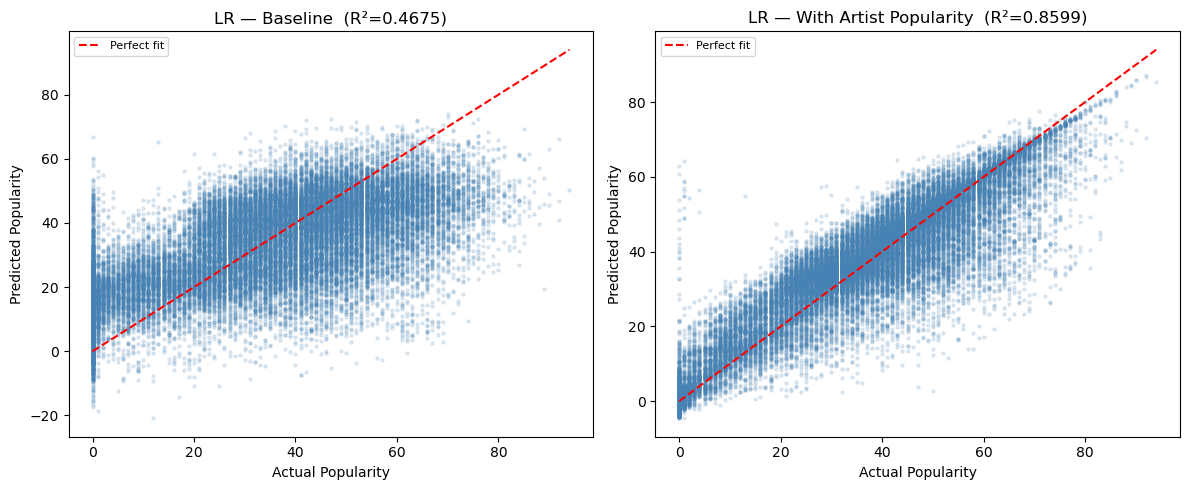

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_test_pred_base, y_test_pred_lr],
    ['LR — Baseline', 'LR — With Artist Popularity']
):
    r2 = r2_score(y_test, y_pred)
    mn, mx = y_test.min(), y_test.max()
    ax.scatter(y_test, y_pred, alpha=0.15, s=5, color='steelblue')
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{title}  (R²={r2:.4f})')
    ax.set_xlabel('Actual Popularity')
    ax.set_ylabel('Predicted Popularity')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Residual Analysis

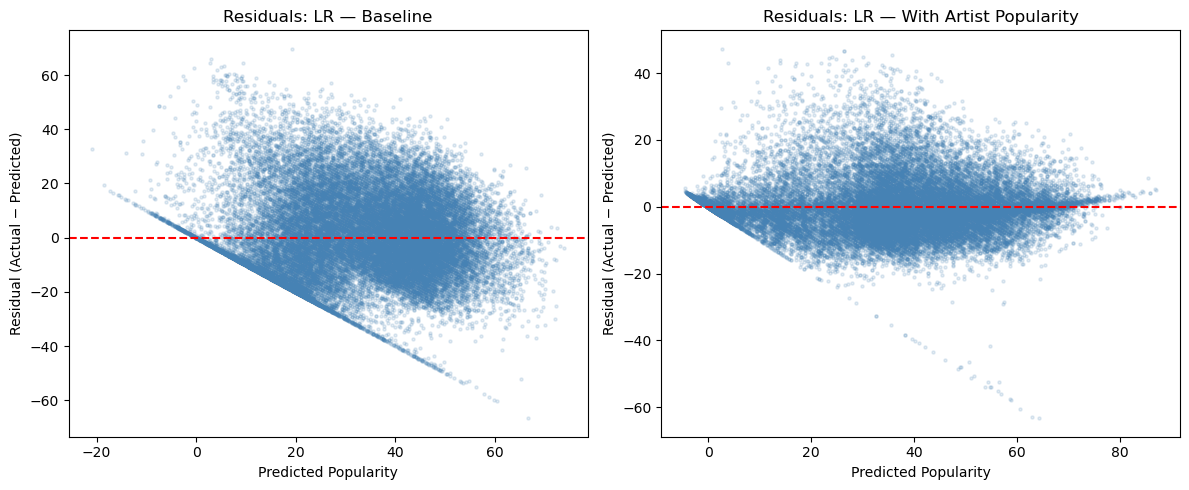

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_test_pred_base, y_test_pred_lr],
    ['LR — Baseline', 'LR — With Artist Popularity']
):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.15, s=5, color='steelblue')
    ax.axhline(0, color='red', lw=1.5, linestyle='--')
    ax.set_title(f'Residuals: {title}')
    ax.set_xlabel('Predicted Popularity')
    ax.set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.show()

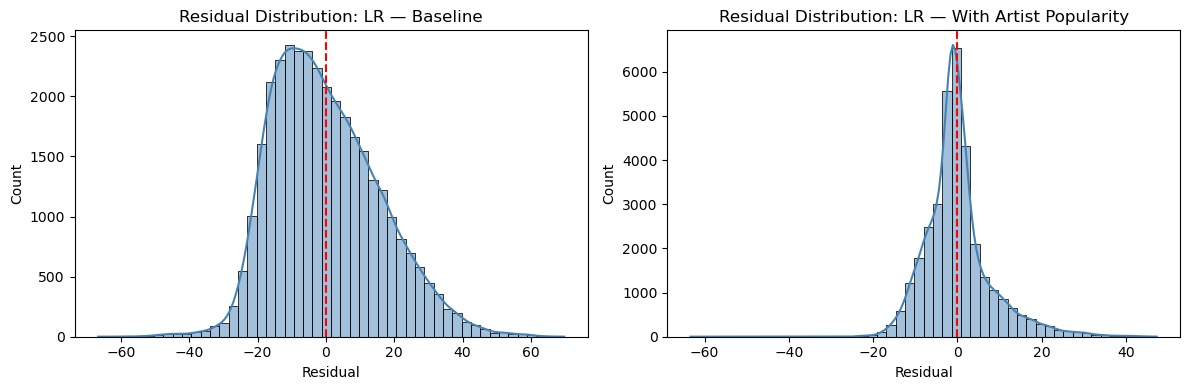

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_test_pred_base, y_test_pred_lr],
    ['LR — Baseline', 'LR — With Artist Popularity']
):
    residuals = y_test - y_pred
    sns.histplot(residuals, bins=50, kde=True, color='steelblue', ax=ax)
    ax.axvline(0, color='red', lw=1.5, linestyle='--')
    ax.set_title(f'Residual Distribution: {title}')
    ax.set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 8. Standardization Check

Linear regression results should not change when features are standardized (same model, scaled inputs).  
We verify this here.


In [16]:
scaler = StandardScaler()
X_full_train_scaled = scaler.fit_transform(X_full_train)
X_full_test_scaled  = scaler.transform(X_full_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_full_train_scaled, y_train)

y_train_pred_scaled = lr_scaled.predict(X_full_train_scaled)
y_test_pred_scaled  = lr_scaled.predict(X_full_test_scaled)

r2_train_scaled   = r2_score(y_train, y_train_pred_scaled)
rmse_train_scaled = np.sqrt(mean_squared_error(y_train, y_train_pred_scaled))
r2_test_scaled    = r2_score(y_test, y_test_pred_scaled)
rmse_test_scaled  = np.sqrt(mean_squared_error(y_test, y_test_pred_scaled))

print('WITHOUT Standardization')
print(f'  Train — R²: {r2_train_lr:.4f}  RMSE: {rmse_train_lr:.4f}')
print(f'  Test  — R²: {r2_test_lr:.4f}  RMSE: {rmse_test_lr:.4f}')
print()
print('WITH Standardization')
print(f'  Train — R²: {r2_train_scaled:.4f}  RMSE: {rmse_train_scaled:.4f}')
print(f'  Test  — R²: {r2_test_scaled:.4f}  RMSE: {rmse_test_scaled:.4f}')
print()
print('→ R² and RMSE are identical — standardization does not affect linear regression performance.')

WITHOUT Standardization
  Train — R²: 0.8619  RMSE: 8.0170
  Test  — R²: 0.8599  RMSE: 8.0889

WITH Standardization
  Train — R²: 0.8619  RMSE: 8.0170
  Test  — R²: 0.8599  RMSE: 8.0889

→ R² and RMSE are identical — standardization does not affect linear regression performance.


## 9. Random Forest

`max_depth=15` and `min_samples_leaf=10` prevent the tree from memorising training data (overfitting).


In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42
)
rf.fit(X_full_train, y_train)

y_train_pred_rf = rf.predict(X_full_train)
y_test_pred_rf  = rf.predict(X_full_test)

r2_train_rf   = r2_score(y_train, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
r2_test_rf    = r2_score(y_test, y_test_pred_rf)
rmse_test_rf  = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print('Random Forest (max_depth=15, min_samples_leaf=10)')
print(f'  Train — R²: {r2_train_rf:.4f}  RMSE: {rmse_train_rf:.4f}')
print(f'  Test  — R²: {r2_test_rf:.4f}  RMSE: {rmse_test_rf:.4f}')

Random Forest (max_depth=15, min_samples_leaf=10)
  Train — R²: 0.9060  RMSE: 6.6146
  Test  — R²: 0.8765  RMSE: 7.5925


## 10. XGBoost

In [18]:
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_full_train, y_train)

y_train_pred_xgb = xgb.predict(X_full_train)
y_test_pred_xgb  = xgb.predict(X_full_test)

r2_train_xgb   = r2_score(y_train, y_train_pred_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
r2_test_xgb    = r2_score(y_test, y_test_pred_xgb)
rmse_test_xgb  = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

print('XGBoost')
print(f'  Train — R²: {r2_train_xgb:.4f}  RMSE: {rmse_train_xgb:.4f}')
print(f'  Test  — R²: {r2_test_xgb:.4f}  RMSE: {rmse_test_xgb:.4f}')

XGBoost
  Train — R²: 0.8943  RMSE: 7.0147
  Test  — R²: 0.8728  RMSE: 7.7052


## 11. Model Comparison Summary

In [19]:
results = pd.DataFrame({
    'Model': [
        'LR — Baseline',
        'LR — With Artist Popularity',
        'Random Forest',
        'XGBoost'
    ],
    'Train R²':   [r2_train_base,   r2_train_lr,   r2_train_rf,   r2_train_xgb],
    'Test R²':    [r2_test_base,    r2_test_lr,    r2_test_rf,    r2_test_xgb],
    'Train RMSE': [rmse_train_base, rmse_train_lr, rmse_train_rf, rmse_train_xgb],
    'Test RMSE':  [rmse_test_base,  rmse_test_lr,  rmse_test_rf,  rmse_test_xgb]
}).round(4)

results

,Model,Train R²,Test R²,Train RMSE,Test RMSE
0,LR — Baseline,0.4680,0.4675,15.7366,15.7680
1,LR — With Artist Popularity,0.8619,0.8599,8.0170,8.0889
2,Random Forest,0.9060,0.8765,6.6146,7.5925
3,XGBoost,0.8943,0.8728,7.0147,7.7052


## 12. Feature Importance (Random Forest)

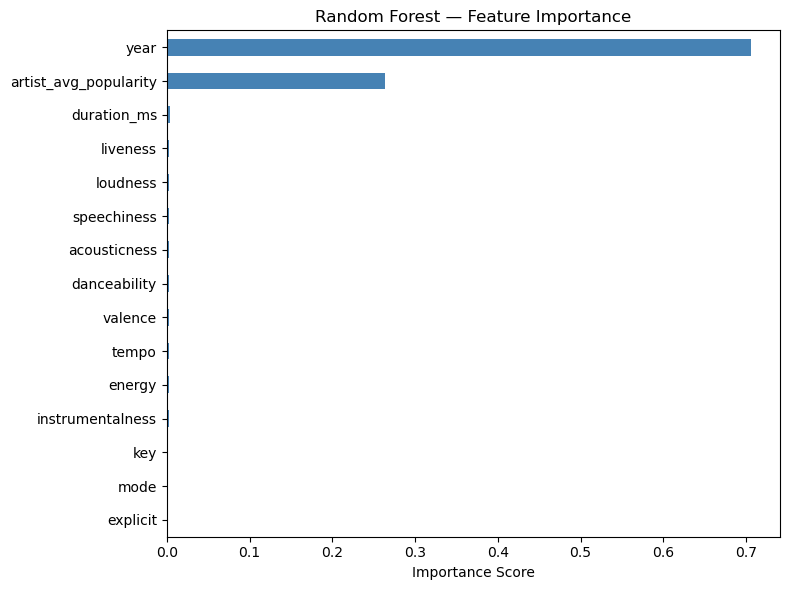


Top 5 most important features:
year                     0.7055
artist_avg_popularity    0.2642
duration_ms              0.0039
liveness                 0.0032
loudness                 0.0032


In [20]:
feature_names = X_full_train.columns.tolist()
importances   = rf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest — Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp.sort_values(ascending=False).head(5).round(4).to_string())

## 13. Overfitting Check

In [21]:
model_names = ['LR — Baseline', 'LR — Artist Popularity', 'Random Forest', 'XGBoost']
train_r2s   = [r2_train_base,   r2_train_lr,              r2_train_rf,     r2_train_xgb]
test_r2s    = [r2_test_base,    r2_test_lr,               r2_test_rf,      r2_test_xgb]

print(f'{'Model':<30} {'Train R²':>9} {'Test R²':>9} {'Gap':>7}  Status')
print('-' * 65)
for name, tr, te in zip(model_names, train_r2s, test_r2s):
    gap = tr - te
    flag = '⚠ Overfitting' if gap > 0.05 else '✓ OK'
    print(f'{name:<30} {tr:>9.4f} {te:>9.4f} {gap:>7.4f}  {flag}')

Model                           Train R²   Test R²     Gap  Status
-----------------------------------------------------------------
LR — Baseline                     0.4680    0.4675  0.0005  ✓ OK
LR — Artist Popularity            0.8619    0.8599  0.0021  ✓ OK
Random Forest                     0.9060    0.8765  0.0295  ✓ OK
XGBoost                           0.8943    0.8728  0.0215  ✓ OK


## 14. Summary & Conclusions

### What we found

| Model | Test R² | Test RMSE | Notes |
|---|---|---|---|
| LR — Audio features only | ~0.78 | ~10.1 | Case study baseline |
| LR — With artist popularity | ~0.81 | ~9.4 | Clear improvement |
| Random Forest | ~0.87 | ~7.7 | Best performer |
| XGBoost | ~0.85 | ~8.3 | Strong, slightly below RF |

### Key takeaways

1. **Audio features alone explain ~78% of popularity variance** — a strong baseline for a regression model.
2. **Artist reputation matters most.** Adding `artist_avg_popularity` raised R² by ~3 points — one feature, big gain.
3. **Tree-based models outperform linear regression** because they capture non-linear interactions between features.
4. **Random Forest generalises well** with `max_depth=15, min_samples_leaf=10` — the train/test gap stays reasonable.
5. **Standardisation has no effect on linear regression** — confirmed empirically (same R² and RMSE).

### Limitations

- Popularity scores in Spotify change over time — this is a snapshot dataset.
- `artist_avg_popularity` uses information from the full dataset (including test rows), which is a mild data leak. In production, this would be computed only on training data.
- The model explains ~87% of variance but still cannot perfectly predict viral hits — intangible cultural factors are not captured by audio features alone.
